# Predicting Silent Customer Churn in Retail Using Temporal RFM Trajectory Patterns and Explainable Machine Learning

---

### Research Overview
The central hypothesis is that **temporal RFM trajectory patterns** : features derived from how a customer's purchasing behaviour *changes over time*, outperform the traditional **static RFM** snapshot at detecting **silent churners**: customers who were recently active but are gradually disengaging and will ultimately stop purchasing.

**Why this matters:** Silent churners are the most dangerous segment for a retailer because they still *look* active at a surface level. A standard churn model lumps them in with obviously lapsed customers, missing the window where a targeted retention campaign could bring them back. By modelling the *trajectory* of engagement (declining frequency, shrinking spend, lengthening gaps between purchases), we can flag these customers before they disappear entirely.


## Section 1: Environment Setup & Configuration

In [1]:
import warnings
import json
import joblib
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Scikit-learn: modelling, preprocessing, evaluation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
)
from sklearn.preprocessing import RobustScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
)

# Imbalanced-learn for SMOTE oversampling
from imblearn.over_sampling import SMOTE
# XGBoost for gradient-boosted trees
from xgboost import XGBClassifier
# SHAP for model explainability
import shap

warnings.filterwarnings("ignore")

# Single global seed used everywhere for reporducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plots setup 
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 130,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.frameon": True,
    "figure.autolayout": True,
})
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

# --- Output directories ---
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)
MODELS_DIR = ARTIFACT_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Random state:", RANDOM_STATE)
print("Artifact dir:", ARTIFACT_DIR.resolve())
print("Models dir  :", MODELS_DIR.resolve())


Random state: 42
Artifact dir: D:\Softwarica\ML\Assignment\artifacts
Models dir  : D:\Softwarica\ML\Assignment\artifacts\models


c:\Users\sajan.mahat\envs\ml-assignment\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Section 2: Data Loading & Overview

We load the UCI **Online Retail II** dataset, a widely-used benchmark in customer analytics research.


In [2]:
RAW_CSV = Path("online_retail_II.csv")
assert RAW_CSV.exists(), f"missing: {RAW_CSV}"

raw = pd.read_csv(
    RAW_CSV,
    dtype={
        "Invoice": "string",
        "StockCode": "string",
        "Description": "string",
        "Country": "string",
    },
    parse_dates=["InvoiceDate"],
    low_memory=False,
)
raw["Customer_ID"] = pd.to_numeric(raw["Customer_ID"], errors="coerce").astype("Int64")
print("Raw shape:", raw.shape)
print("Date range:", raw["InvoiceDate"].min(), "->", raw["InvoiceDate"].max())
raw.dtypes


Raw shape: (1067371, 8)
Date range: 2009-12-01 07:45:00 -> 2011-12-09 12:50:00


Invoice                string
StockCode              string
Description            string
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer_ID             Int64
Country                string
dtype: object

In [3]:
# See how many distinct values are there for each of the columns
print("Distinct values:")
for c in ["Invoice", "StockCode", "Customer_ID", "Country"]:
    print(f"  {c}: {raw[c].nunique():,}")
print("\nFirst 3 rows:")
display(raw.head(3))
print("Last 3 rows:")
display(raw.tail(3))


Distinct values:
  Invoice: 53,628
  StockCode: 5,304
  Customer_ID: 5,942
  Country: 43

First 3 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom


Last 3 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680,France


## Section 3: Data Quality & Cleaning

This section applies a systematic sequence of quality filters, each justified by a specific data-quality concern. The cleaning process omitted these following thigs:

| Filter | Why it is applied |
|--------|-------------------|
| **Null `Customer_ID`** | A customer-level model cannot use transactions that are not attributed to anyone. |
| **Cancelled invoices** (prefix `C`) | Cancellations produce negative quantities and would double-count items that were bought then returned. |
| **Non-positive `Quantity` / `Price`** | These are data-entry artefacts — a product cannot have zero or negative price or quantity. |
| **Alphabetic-only `StockCode`** | Codes like `POST`, `BANK CHARGES`, `AMAZONFEE`, `M`, `S` are administrative line items (shipping, fees), not products. Including them would distort RFM calculations. |
| **Exact duplicate rows** | Pure ingestion-level duplicates inflate frequency and revenue. |

After cleaning, we compute `Revenue = Quantity × Price` for each line item. Every step prints before/after row counts so the entire funnel is auditable and reproducible.


In [4]:
quality = pd.DataFrame({
    "metric": [
        "rows",
        "null Customer_ID",
        "Cancelled invoice (C-prefix)",
        "Quantity <= 0",
        "Price <= 0",
        "Alphabetic-only StockCode",
        "Exact duplicates",
    ],
    "count": [
        len(raw),
        raw["Customer_ID"].isna().sum(),
        raw["Invoice"].str.startswith("C", na=False).sum(),
        (raw["Quantity"] <= 0).sum(),
        (raw["Price"] <= 0).sum(),
        (~raw["StockCode"].str.contains(r"\d", na=False)).sum(),
        raw.duplicated().sum(),
    ],
})
quality["Percent of Total"] = (quality["count"] / len(raw) * 100).round(3)
quality


,metric,count,Percent of Total
0,rows,1067371,100.000
1,null Customer_ID,243007,22.767
2,Cancelled invoice (C-prefix),19494,1.826
3,Quantity <= 0,22950,2.150
4,Price <= 0,6207,0.582
5,Alphabetic-only StockCode,5579,0.523
6,Exact duplicates,34335,3.217


In [5]:
def clean_dataset(df: pd.DataFrame) -> pd.DataFrame:
    counts = {"start": len(df)}
    df = df[df["Customer_ID"].notna()].copy()
    counts["after_drop_null_customer"] = len(df)

    df = df[~df["Invoice"].str.startswith("C", na=False)]
    counts["after_drop_cancelled"] = len(df)

    df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]
    counts["after_drop_nonpositive"] = len(df)

    df = df[df["StockCode"].str.contains(r"\d", na=False)]
    counts["after_drop_alpha_stockcode"] = len(df)

    df = df.drop_duplicates()
    counts["after_drop_duplicates"] = len(df)

    df["Revenue"] = df["Quantity"] * df["Price"]
    df["Customer_ID"] = df["Customer_ID"].astype("int64")
    return df, counts

clean, counts = clean_dataset(raw)
funnel = pd.Series(counts).to_frame("rows")
funnel["Percent of Raw Data"] = (funnel["rows"] / counts["start"] * 100).round(2)
print(funnel)
print(f"\nCleaned Customers : {clean['Customer_ID'].nunique():,}")
print(f"Cleaned Invoices  : {clean['Invoice'].nunique():,}")


                               rows  Percent of Raw Data
start                       1067371               100.00
after_drop_null_customer     824364                77.23
after_drop_cancelled         805620                75.48
after_drop_nonpositive       805549                75.47
after_drop_alpha_stockcode   802900                75.22
after_drop_duplicates        776840                72.78

Cleaned Customers : 5,853
Cleaned Invoices  : 36,613


### Filter to customers with ≥ 3 distinct invoices

The temporal feature engineering needs *enough purchase history to estimate a trajectory*. A customer with only one or two invoices has no inter-purchase gap, no last-3-vs-first-3 ratio, and no streak structure — every temporal feature would collapse to zero or NaN. Dropping these customers does not bias the silent-churn analysis because the silent-churn pattern is, by definition, only meaningful for customers with enough history to show a *trend*.


In [6]:
inv_per_cust = clean.groupby("Customer_ID")["Invoice"].nunique()
keep_customers = inv_per_cust[inv_per_cust >= 3].index
before_n = clean["Customer_ID"].nunique()
clean = clean[clean["Customer_ID"].isin(keep_customers)].copy()
after_n = clean["Customer_ID"].nunique()
print(f"Customers before filter : {before_n:,}")
print(f"Customers after  filter : {after_n:,}")
print(f"Rows after filter       : {len(clean):,}")
print(f"Final date range        : {clean['InvoiceDate'].min()} -> {clean['InvoiceDate'].max()}")

Customers before filter : 5,853
Customers after  filter : 3,290
Rows after filter       : 702,279
Final date range        : 2009-12-01 07:45:00 -> 2011-12-09 12:50:00


## Section 4: Exploratory Data Analysis

This EDA section examines:

1. **Temporal patterns**: how transaction volume varies month-to-month (important for understanding seasonality and choosing window boundaries).
2. **Geographic distribution**: which countries contribute most to the customer base (the dataset is dominated by UK customers).
3. **Customer-level statistics**: distributions of invoice counts, revenue, and active periods per customer (this informs our feature engineering choices).
4. **Customer activity heatmap**: a visual representation of when customers are active vs. inactive across the observation window, which directly motivates the temporal features we will build.


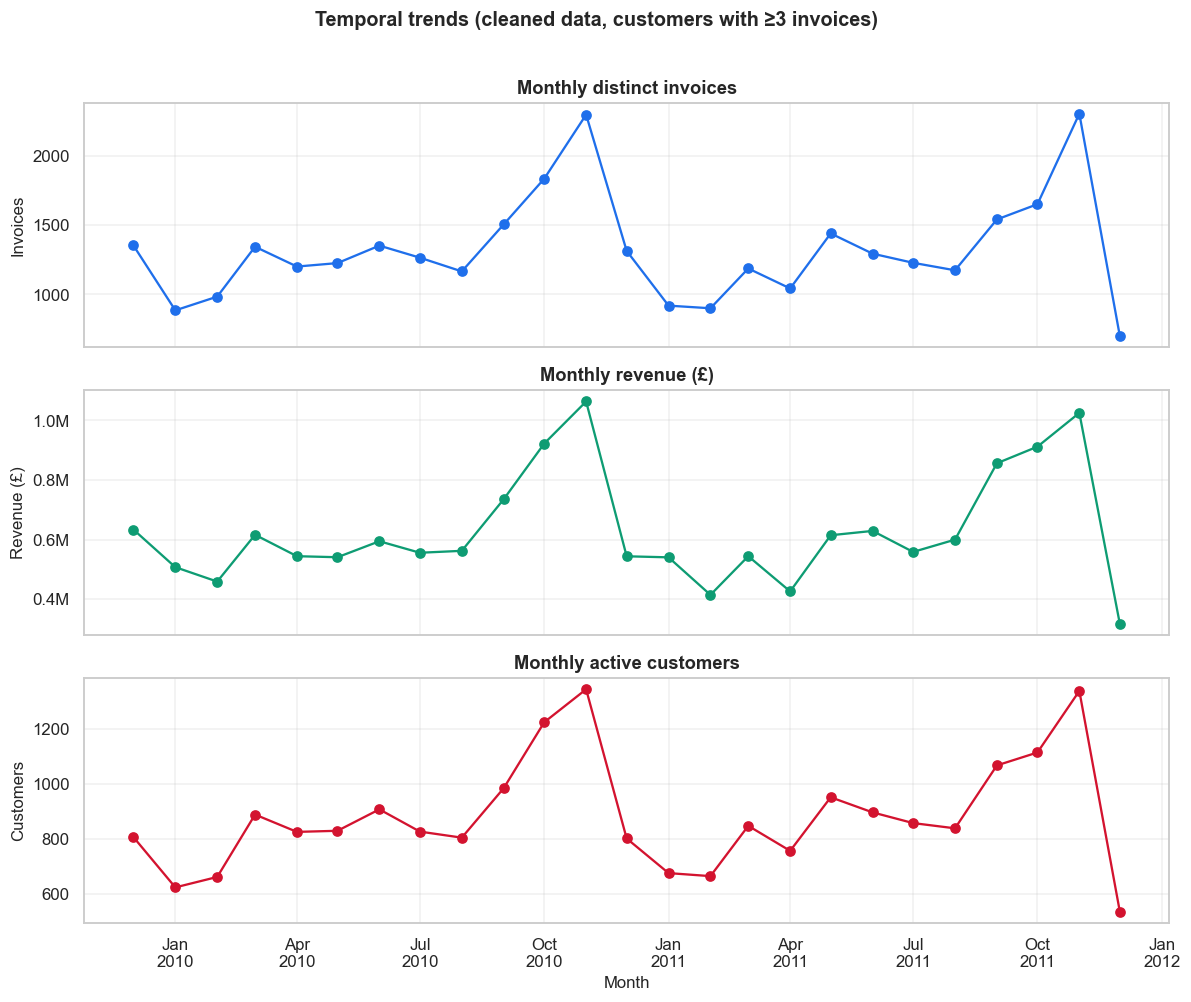

In [7]:
clean["YearMonth"] = clean["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
monthly = (
    clean.groupby("YearMonth")
    .agg(
        transactions=("Invoice", "nunique"),
        revenue=("Revenue", "sum"),
        active_customers=("Customer_ID", "nunique"),
    )
    .reset_index()
)

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
axes[0].plot(monthly["YearMonth"], monthly["transactions"], marker="o", color="#1f6feb")
axes[0].set_title("Monthly distinct invoices")
axes[0].set_ylabel("Invoices")
axes[1].plot(monthly["YearMonth"], monthly["revenue"], marker="o", color="#0e9c73")
axes[1].set_title("Monthly revenue (£)")
axes[1].set_ylabel("Revenue (£)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
axes[2].plot(monthly["YearMonth"], monthly["active_customers"], marker="o", color="#d3132f")
axes[2].set_title("Monthly active customers")
axes[2].set_ylabel("Customers")
axes[2].set_xlabel("Month")
for a in axes:
    a.grid(alpha=0.3)
    a.xaxis.set_major_locator(mdates.MonthLocator(bymonth=range(1, 13, 3)))
    a.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
plt.suptitle("Temporal trends (cleaned data, customers with ≥3 invoices)", y=1.01, fontsize=13, fontweight="bold")
plt.show()


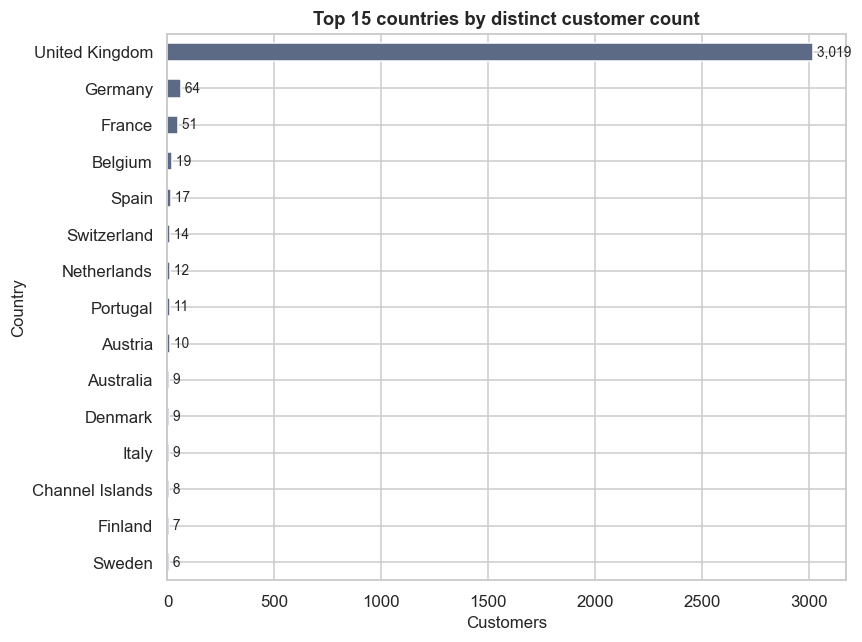

In [8]:
#Data by country analysis
country_counts = (
    clean.groupby("Country")["Customer_ID"].nunique().sort_values(ascending=True).tail(15)
)
fig, ax = plt.subplots(figsize=(8, 6))
country_counts.plot(kind="barh", ax=ax, color="#5d6a85")
ax.set_title("Top 15 countries by distinct customer count")
ax.set_xlabel("Customers")
ax.set_ylabel("Country")
for i, (country, val) in enumerate(country_counts.items()):
    ax.text(val, i, f" {val:,}", va="center", fontsize=9)
plt.show()


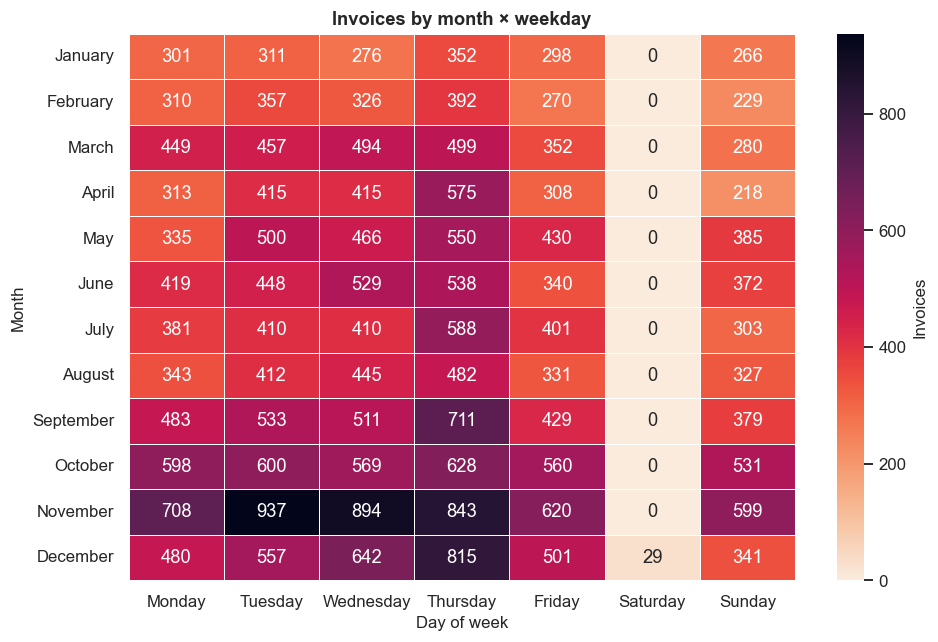

In [9]:
# Visualize transaction seasonality by month and weekday.
# This heatmap shows the number of distinct invoices generated for each
# month-day combination, helping identify temporal purchasing patterns
# such as busier months, slower periods, or weekday-specific activity.
# Understanding these seasonal and weekly patterns is useful before churn modelling,
# because customer inactivity may be affected by normal business seasonality rather
# than true churn behaviour.

heat = (
    clean.assign(
        Month=clean["InvoiceDate"].dt.month_name(),
        DOW=clean["InvoiceDate"].dt.day_name(),
    )
    .groupby(["Month", "DOW"])["Invoice"].nunique()
    .unstack(fill_value=0)
)
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
heat = heat.reindex(index=[m for m in month_order if m in heat.index],
                    columns=[d for d in dow_order if d in heat.columns])

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(heat, annot=True, fmt="d", cmap="rocket_r", linewidths=0.4, ax=ax,
            cbar_kws={"label": "Invoices"})
ax.set_title("Invoices by month × weekday")
ax.set_xlabel("Day of week")
ax.set_ylabel("Month")
plt.show()


## Section 5: Static RFM Features (Literature-Validated Baseline)

We compute the canonical **3-feature RFM vector** per customer over the **observation window** (Dec 2009 – May 2011, 18 months). These features form the *Static* baseline used in experiments A1/A2/A3.

### Why Static RFM as the baseline?

The RFM framework (Recency, Frequency, Monetary) was originally proposed by Hughes (1994) and is the most widely-used customer segmentation method in direct marketing and churn prediction literature. We use it as our baseline because it is the **standard benchmark**, our goal is to show whether temporal trajectory features add value *beyond* what the established static RFM already captures.


In [10]:
# Define the observation and prediction windows for churn modelling.
# The observation window contains historical customer transactions used to build
# RFM and temporal behaviour features.

OBS_START = pd.Timestamp("2009-12-01")
OBS_END   = pd.Timestamp("2011-05-31 23:59:59")
PRED_START = pd.Timestamp("2011-06-01")
PRED_END   = pd.Timestamp("2011-12-09 23:59:59")
LAST3_START = pd.Timestamp("2011-03-01")

obs = clean[(clean["InvoiceDate"] >= OBS_START) & (clean["InvoiceDate"] <= OBS_END)].copy()
pred = clean[(clean["InvoiceDate"] >= PRED_START) & (clean["InvoiceDate"] <= PRED_END)].copy()

print(f"Observation rows : {len(obs):,}  ({obs['Customer_ID'].nunique():,} customers)")
print(f"Prediction rows  : {len(pred):,}  ({pred['Customer_ID'].nunique():,} customers)")

Observation rows : 481,199  (3,043 customers)
Prediction rows  : 221,080  (2,597 customers)


In [11]:
# Reference date for recency = end of the observation window.
# Recency is defined as the number of days between this date and
# the customer's most recent purchase (standard in RFM literature).
ref_date = OBS_END

# Compute the three canonical RFM features per customer:
#   R = days since last purchase (lower = more recently active)
#   F = count of distinct invoices (unique transactions, not items)
#   M = total revenue across all transactions in the observation window
static_rfm = (
    obs.groupby("Customer_ID")
    .agg(
        last_purchase=("InvoiceDate", "max"),     # most recent purchase date
        frequency=("Invoice", "nunique"),          # distinct invoice count
        monetary=("Revenue", "sum"),               # total spend (Quantity × Price)
    )
)
static_rfm["recency_days"] = (ref_date - static_rfm["last_purchase"]).dt.days
static_rfm = static_rfm[["recency_days", "frequency", "monetary"]]

print(f"Customers in static RFM: {len(static_rfm)}")
print(f"\nDescriptive statistics of the 3 static RFM features:")
print(static_rfm.describe().round(2))


Customers in static RFM: 3043

Descriptive statistics of the 3 static RFM features:
       recency_days  frequency   monetary
count       3043.00    3043.00    3043.00
mean         112.87       7.63    3555.69
std          105.87      11.94   13157.59
min            0.00       1.00      17.70
25%           23.00       3.00     702.78
50%           74.00       5.00    1422.77
75%          188.00       8.00    3009.02
max          544.00     235.00  385971.85


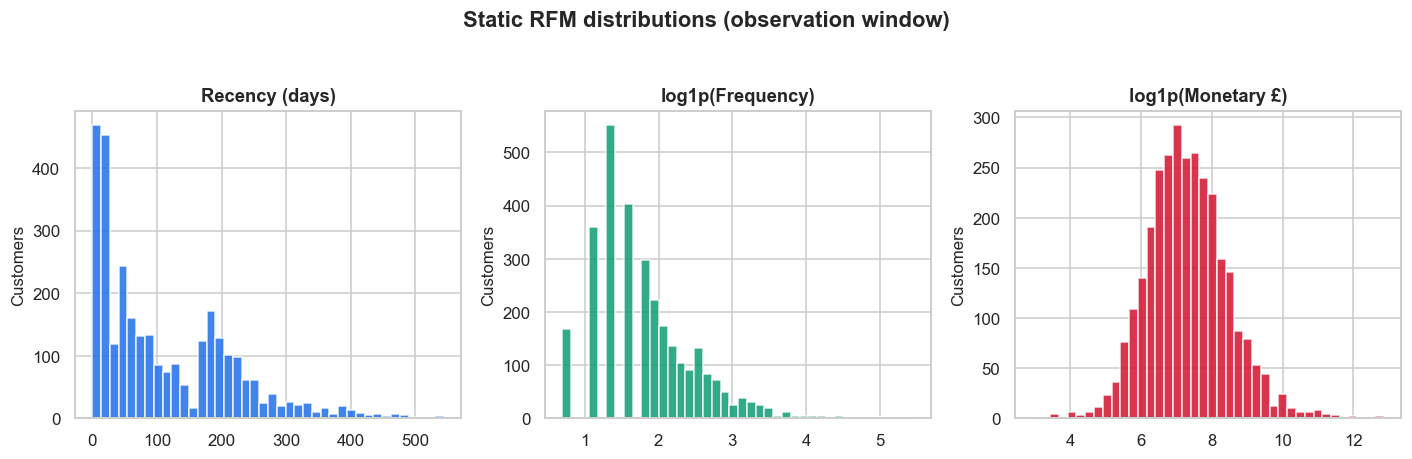

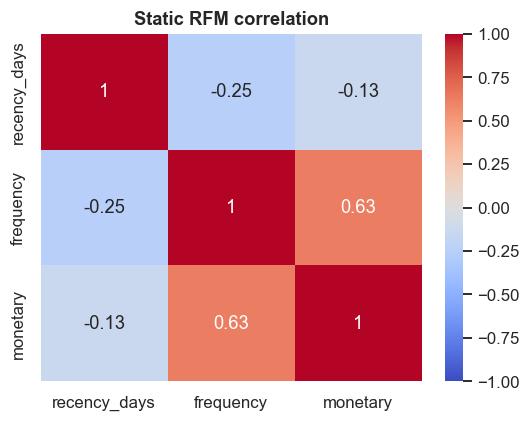

In [12]:
# Explore the distribution and correlation of static RFM features.
# The first set of histograms shows how recency, frequency, and monetary value are distributed across customers within the observation window.
# Frequency and monetary are log-transformed using log1p to reduce skewness and make heavily right-skewed customer behaviour easier to visualize.

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].hist(static_rfm["recency_days"], bins=40, color="#1f6feb", alpha=0.85)
axes[0].set_title("Recency (days)")
axes[1].hist(np.log1p(static_rfm["frequency"]), bins=40, color="#0e9c73", alpha=0.85)
axes[1].set_title("log1p(Frequency)")
axes[2].hist(np.log1p(static_rfm["monetary"]), bins=40, color="#d3132f", alpha=0.85)
axes[2].set_title("log1p(Monetary £)")
for a in axes:
    a.set_ylabel("Customers")
plt.suptitle("Static RFM distributions (observation window)", y=1.04, fontweight="bold")
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(static_rfm.corr(), annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Static RFM correlation")
plt.show()


## Section 6: Temporal RFM and Micro-Pattern Features

### Why temporal features?

The core limitation of static RFM is that it compresses an entire customer relationship into just three numbers. A customer who purchased steadily for 18 months and a customer who purchased heavily in month 1 but then went silent for 17 months can have *identical* static RFM values (same recency, same total frequency, same total monetary). The static snapshot cannot distinguish these two fundamentally different engagement patterns.

**Temporal features solve this** by capturing *how* a customer's behaviour changes over time: the trajectory of engagement, not just its endpoint. This is precisely what makes silent churners detectable: their trajectories show a gradual decline that the static snapshot hides.

### How we build the features

We construct a dense **customer × month panel** of the 18-month observation window (one row per customer per month, filling in zeros for months with no activity). From this panel we derive **nine descriptive-statistic features**:

| Feature | What it captures | Why it matters for silent churn |
|---------|-----------------|-------------------------------|
| `freq_trend` | Change in monthly invoice count (last 3 months mean − first 3 months mean) | Negative → declining purchase frequency |
| `monetary_trend` | Same idea applied to monthly revenue | Negative → shrinking spend per month |
| `recency_trend` | Same idea applied to within-month recency | Positive → growing gap since last purchase |
| `consec_inactive_months` | Longest streak of zero-purchase months | Captures "quiet stretches" that trends miss |
| `gap_mean` | Average inter-purchase gap in days | Direct measure of purchase cadence |
| `gap_std` | Standard deviation of inter-purchase gaps | High → erratic buyer; low → consistent |
| `freq_last3_vs_first3` | Ratio of late-vs-early frequency | Robust to magnitude differences across customers |
| `monetary_cv` | Coefficient of variation of monthly spend (σ/μ) | Distinguishes steady vs. feast-and-famine spenders |
| `active_month_ratio` | Proportion of months with ≥1 purchase | Simple but robust "engagement breadth" measure |

In [13]:
# Build a monthly customer-level RFM panel from the observation window.
# Each customer is represented across all 18 monthly periods from December 2009
# to May 2011, even if they did not make a purchase in a specific month.

months = pd.date_range("2009-12-01", "2011-05-01", freq="MS")  # 18 month-starts
obs2 = obs.assign(YearMonth=obs["InvoiceDate"].values.astype("datetime64[M]"))

monthly_per_cust = (
    obs2.groupby(["Customer_ID", "YearMonth"])
        .agg(freq_t=("Invoice", "nunique"),
             monetary_t=("Revenue", "sum"),
             last_purchase=("InvoiceDate", "max"))
        .reset_index()
)

cust_idx = pd.Index(obs["Customer_ID"].unique(), name="Customer_ID")
month_idx = pd.Index(months, name="YearMonth")
panel = (
    monthly_per_cust.set_index(["Customer_ID", "YearMonth"])
                    .reindex(pd.MultiIndex.from_product([cust_idx, month_idx],
                                                        names=["Customer_ID", "YearMonth"]))
)
panel["freq_t"] = panel["freq_t"].fillna(0).astype(int)
panel["monetary_t"] = panel["monetary_t"].fillna(0.0)

panel = panel.reset_index()
panel = panel.sort_values(["Customer_ID", "YearMonth"]).reset_index(drop=True)
panel["last_purchase"] = panel.groupby("Customer_ID")["last_purchase"].ffill()
month_end = panel["YearMonth"] + pd.offsets.MonthEnd(0)
panel["recency_t"] = (month_end - panel["last_purchase"]).dt.days
panel["recency_t"] = panel["recency_t"].fillna(panel["recency_t"].max() if panel["recency_t"].notna().any() else 0)

print("Panel shape:", panel.shape)
print(panel.head(20))


Panel shape: (54774, 6)
    Customer_ID  YearMonth  freq_t  monetary_t       last_purchase  recency_t
0         12346 2009-12-01       5      113.50 2009-12-18 10:55:00       12.0
1         12346 2010-01-01       4       90.00 2010-01-22 13:30:00        8.0
2         12346 2010-02-01       0        0.00 2010-01-22 13:30:00       36.0
3         12346 2010-03-01       1       27.05 2010-03-02 13:08:00       28.0
4         12346 2010-04-01       0        0.00 2010-03-02 13:08:00       58.0
5         12346 2010-05-01       0        0.00 2010-03-02 13:08:00       89.0
6         12346 2010-06-01       1      142.31 2010-06-28 13:53:00        1.0
7         12346 2010-07-01       0        0.00 2010-06-28 13:53:00       32.0
8         12346 2010-08-01       0        0.00 2010-06-28 13:53:00       63.0
9         12346 2010-09-01       0        0.00 2010-06-28 13:53:00       93.0
10        12346 2010-10-01       0        0.00 2010-06-28 13:53:00      124.0
11        12346 2010-11-01       0      

In [14]:
# Extract temporal RFM trajectory features from the monthly customer panel.
# This step converts each customer's 18-month RFM sequence into summary features
# that describe behaviour change, inactivity, purchase gaps, and spending stability.

def _mean_diff(arr: np.ndarray, k: int = 3) -> float:
    """Difference of means: mean of last k values minus mean of first k values.

    This is a basic descriptive-statistics measure of direction-of-change.
    It is *not* a regression slope — only the arithmetic mean is used.
    Negative => the variable is lower at the end of the window than at the
    start (i.e. declining behaviour).
    """
    if len(arr) < 2 * k:
        return 0.0
    return float(arr[-k:].mean() - arr[:k].mean())

def _longest_run(values: np.ndarray) -> int:
    """Longest consecutive run of 1s in a 0/1 array (simple counting)."""
    run_max = 0
    cur = 0
    for v in values:
        if v == 1:
            cur += 1
            if cur > run_max:
                run_max = cur
        else:
            cur = 0
    return int(run_max)

def temporal_features(group: pd.DataFrame) -> pd.Series:
    freq = group["freq_t"].to_numpy()
    mon  = group["monetary_t"].to_numpy()
    rec  = group["recency_t"].to_numpy()

    freq_trend     = _mean_diff(freq)
    monetary_trend = _mean_diff(mon)
    recency_trend  = _mean_diff(rec)

    inactive = (freq == 0).astype(int)
    consec_inactive_months = _longest_run(inactive)

    purchase_dates = group.loc[group["freq_t"] > 0, "last_purchase"].dropna().sort_values().unique()
    if len(purchase_dates) >= 2:
        gaps = np.diff(pd.to_datetime(purchase_dates)).astype("timedelta64[D]").astype(int)
        gap_mean = float(gaps.mean())
        gap_std  = float(gaps.std(ddof=0))
    else:
        gap_mean = 0.0
        gap_std  = 0.0

    first3_mean = freq[:3].mean()
    last3_mean  = freq[-3:].mean()
    if first3_mean == 0 and last3_mean == 0:
        freq_last3_vs_first3 = 1.0
    elif first3_mean == 0:
        freq_last3_vs_first3 = float(last3_mean) + 1.0
    else:
        freq_last3_vs_first3 = float(last3_mean / first3_mean)

    if mon.mean() > 0:
        monetary_cv = float(mon.std(ddof=0) / mon.mean())
    else:
        monetary_cv = 0.0

    active_month_ratio = float((freq > 0).mean())

    return pd.Series({
        "freq_trend": freq_trend,
        "monetary_trend": monetary_trend,
        "recency_trend": recency_trend,
        "consec_inactive_months": consec_inactive_months,
        "gap_mean": gap_mean,
        "gap_std": gap_std,
        "freq_last3_vs_first3": freq_last3_vs_first3,
        "monetary_cv": monetary_cv,
        "active_month_ratio": active_month_ratio,
    })

temporal_rfm = panel.groupby("Customer_ID", sort=False).apply(temporal_features).reset_index()
temporal_rfm = temporal_rfm.set_index("Customer_ID")
print("Temporal RFM shape:", temporal_rfm.shape)
print(temporal_rfm.describe().round(3))


Temporal RFM shape: (3043, 9)
       freq_trend  monetary_trend  recency_trend  consec_inactive_months  gap_mean   gap_std  freq_last3_vs_first3  monetary_cv  active_month_ratio
count    3043.000        3043.000       3043.000                3043.000  3043.000  3043.000              3043.000     3043.000            3043.000
mean        0.049          -1.663       -243.761                   7.313    85.375    29.590                 1.041        2.185               0.282
std         0.741         773.626        235.905                   3.847    66.626    30.886                 0.824        0.893               0.204
min       -12.000      -25769.473       -542.667                   0.000     0.000     0.000                 0.000        0.253               0.056
25%        -0.333         -71.130       -461.167                   4.000    42.958     0.000                 0.500        1.539               0.111
50%         0.000           0.000       -329.667                   7.000    69.667

In [15]:
# Clean and cap extreme values in the temporal RFM feature table.
# Some temporal features, such as gap statistics, frequency ratios, or monetary
# variability, can contain missing values, infinite values, or extreme outliers.

def cap_outliers(df: pd.DataFrame, q: float = 0.99) -> pd.DataFrame:
    capped = df.replace([np.inf, -np.inf], np.nan).copy()
    for c in capped.columns:
        if capped[c].isna().any():
            capped[c] = capped[c].fillna(capped[c].median())
        upper = capped[c].quantile(q)
        capped[c] = capped[c].clip(upper=upper)
    return capped

temporal_rfm = cap_outliers(temporal_rfm)
print("Any NaN/inf left?", temporal_rfm.isna().any().any(), np.isinf(temporal_rfm.values).any())


Any NaN/inf left? False False


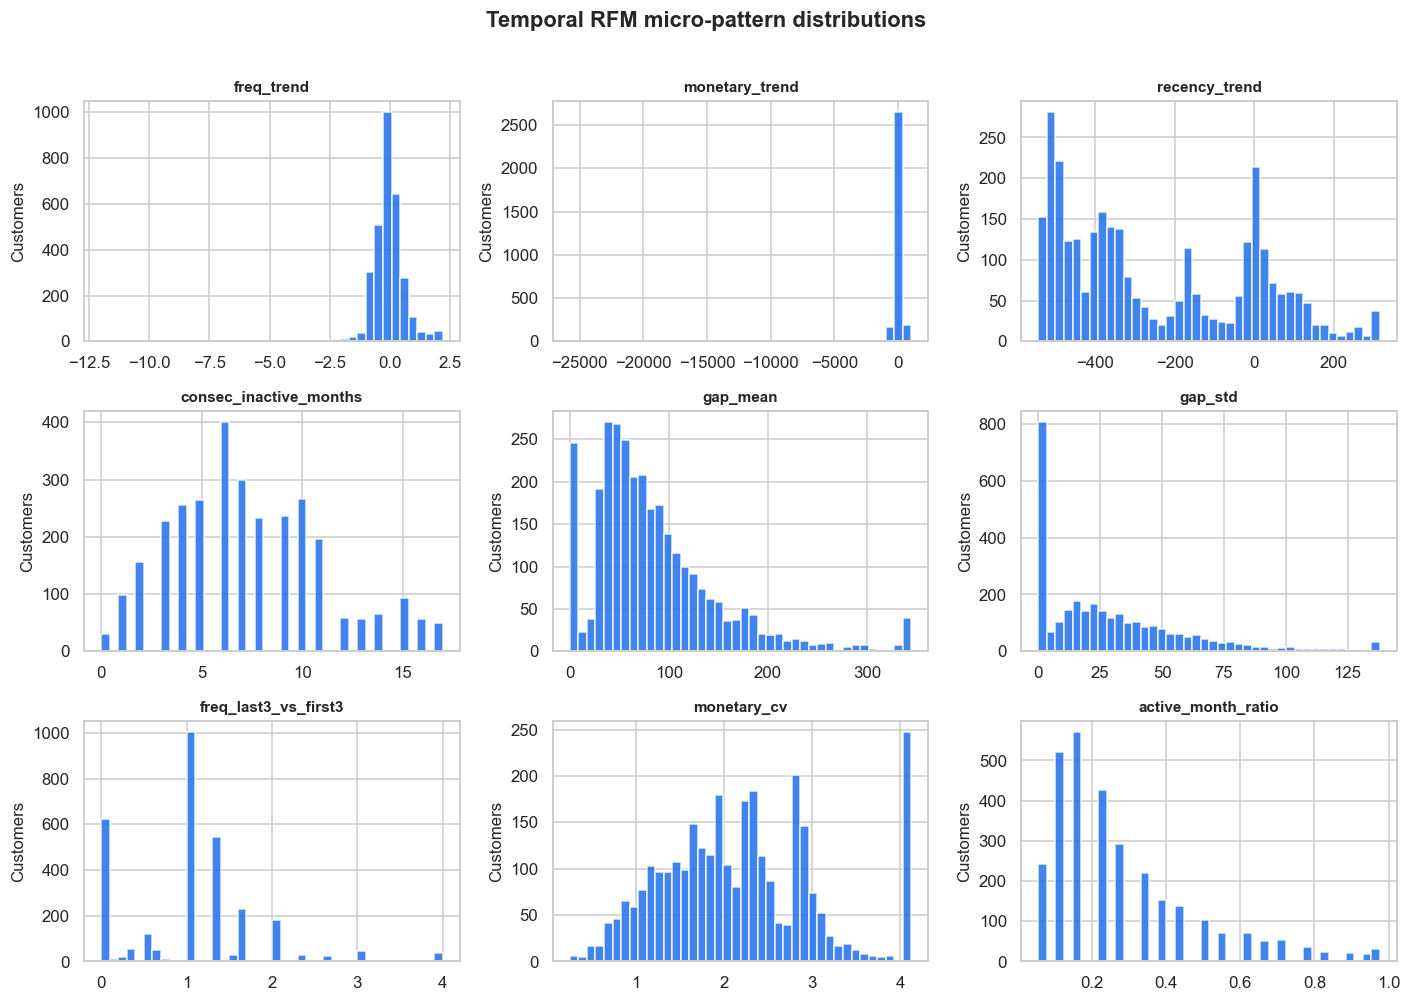

In [16]:
#Temporal RFM micro pattern distributions
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, col in zip(axes.flat, temporal_rfm.columns):
    ax.hist(temporal_rfm[col], bins=40, color="#1f6feb", alpha=0.85)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("Customers")
plt.suptitle("Temporal RFM micro-pattern distributions", y=1.01, fontweight="bold")
plt.show()


## Section 7: Multi-class Labelling, Customer-level 80/20 Split, SMOTE

This section performs three critical preprocessing steps before model training:

### 7.1: Label assignment (3-class)

We assign each customer to one of three classes based on their behaviour in the **prediction window** (Jun 2011 – Dec 2011):

* A customer is labelled Active if they made at least one purchase in the prediction window.
* A customer is labelled Regular Churn if they made no purchase in the prediction window.
* A customer is labelled Silent Churn if:
    - They made no purchase in the prediction window.
    - They were still active in the last three months of the observation window.
    - Their behavior was already declining, based on either:

**Why 3 classes instead of binary?** Binary churn (active vs. churned) hides the silent sub-population inside the "churned" class. A binary model has no way to distinguish customers whose disengagement was *gradual* from those who simply stopped. The 3-class formulation explicitly exposes this distinction.

### 7.2: Customer-level stratified train/test split

We split at the **customer level** (not the transaction level) so that the test set contains customers the model has *never seen during training*. Stratification on the 3-class label guarantees that even the rare Class 2 (~2% of the cohort) is represented in both folds. A fixed seed (`random_state=42`) ensures all six experiments use the exact same split.

### 7.3: SMOTE oversampling

Class 2 is ~2% of the cohort — far too rare for most classifiers to learn effectively.SMOTE generates synthetic minority-class examples by interpolating in feature space. Critically, **SMOTE is applied only to the training fold**; the test set retains its natural class distribution so that evaluation metrics reflect real-world performance.


In [17]:
features = static_rfm.join(temporal_rfm, how="inner")
print("Joined feature matrix:", features.shape)

cust_pred = pred.groupby("Customer_ID")["Invoice"].nunique()
purchased_in_pred = features.index.isin(cust_pred.index)

last3 = obs[obs["InvoiceDate"] >= LAST3_START]
active_last3 = last3.groupby("Customer_ID")["Invoice"].nunique()
active_last3_set = set(active_last3.index)

declining = (features["freq_trend"] < 0) | (features["monetary_trend"] < 0)
silent_mask = (~purchased_in_pred) & features.index.isin(active_last3_set) & declining
churn_mask = ~purchased_in_pred

y_multi = pd.Series(0, index=features.index, name="y_multi")
y_multi[churn_mask] = 1
y_multi[silent_mask] = 2
y_bin = (y_multi > 0).astype(int).rename("y_bin")

print("Multi-class distribution:")
print(y_multi.value_counts().rename({0: "0 Active", 1: "1 Regular Churn", 2: "2 Silent Churn"}))


Joined feature matrix: (3043, 12)
Multi-class distribution:
y_multi
0 Active           2350
1 Regular Churn     634
2 Silent Churn       59
Name: count, dtype: int64


In [18]:
# Prepare the final feature matrix and target labels for model training.
# Static RFM features represent overall customer behaviour during the observation window,
# while temporal RFM features capture behavioural changes over time.
# The dataset is split using stratification so that the active, regular churn,
# and silent churn class proportions are preserved in both train and test sets.

STATIC_COLS = ["recency_days", "frequency", "monetary"]

TEMPORAL_COLS = [
    "freq_trend", "monetary_trend", "recency_trend",
    "consec_inactive_months", "gap_mean", "gap_std",
    "freq_last3_vs_first3", "monetary_cv", "active_month_ratio",
]

ALL_COLS = STATIC_COLS + TEMPORAL_COLS

X_full = features[ALL_COLS]
y = y_multi

X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Feature Set Summary")
display(pd.DataFrame({
    "Feature Group": ["Static RFM", "Temporal RFM", "Total"],
    "Number of Features": [len(STATIC_COLS), len(TEMPORAL_COLS), len(ALL_COLS)],
}))

print("Train-Test Split Summary")
display(pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Rows": [X_train.shape[0], X_test.shape[0]],
    "Features": [X_train.shape[1], X_test.shape[1]],
    "Split Ratio": ["80%", "20%"],
}))

class_names = {
    0: "Active",
    1: "Regular Churn",
    2: "Silent Churn",
}

train_dist = y_train.value_counts().sort_index()
test_dist = y_test.value_counts().sort_index()
all_classes = sorted(class_names.keys())

class_distribution = pd.DataFrame({
    "Class": all_classes,
    "Label": [class_names[i] for i in all_classes],
    "Train Count": train_dist.reindex(all_classes, fill_value=0).values,
    "Train %": (train_dist.reindex(all_classes, fill_value=0) / len(y_train) * 100).round(2).values,
    "Test Count": test_dist.reindex(all_classes, fill_value=0).values,
    "Test %": (test_dist.reindex(all_classes, fill_value=0) / len(y_test) * 100).round(2).values,
})

print("Multiclass Target Distribution")
display(class_distribution)

Feature Set Summary


,Feature Group,Number of Features
0,Static RFM,3
1,Temporal RFM,9
2,Total,12


Train-Test Split Summary


,Dataset,Rows,Features,Split Ratio
0,Train,2434,12,80%
1,Test,609,12,20%


Multiclass Target Distribution


,Class,Label,Train Count,Train %,Test Count,Test %
0,0,Active,1880,77.24,470,77.18
1,1,Regular Churn,507,20.83,127,20.85
2,2,Silent Churn,47,1.93,12,1.97


In [19]:
# Scale the feature values using RobustScaler.
# RobustScaler removes the median and scales features using the interquartile range,
# making it less sensitive to extreme values than standard scaling.

scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)
print("Scaler fitted on train, applied to both. Train head:")
display(X_train_scaled.head(3))


Scaler fitted on train, applied to both. Train head:


,recency_days,frequency,monetary,freq_trend,monetary_trend,recency_trend,consec_inactive_months,gap_mean,gap_std,freq_last3_vs_first3,monetary_cv,active_month_ratio
Customer_ID,,,,,,,,,,,,
17774,-0.109091,0.4,0.550916,0.0,-0.327457,0.018750,-0.8,-0.009745,0.087050,0.0,-0.604595,0.75
12433,0.600000,0.0,2.557007,0.0,0.000000,-0.149632,0.2,-0.492113,-0.289951,0.0,0.275264,0.00
14754,0.169697,0.0,-0.117270,-0.5,-0.700674,0.454044,-0.8,0.412936,0.374571,-1.2,-0.098831,0.25


In [20]:
# Apply partial SMOTE to reduce class imbalance without fully equalizing all classes.
# Full SMOTE can make very rare classes, such as Silent Churn, appear as common as
# the majority class, which may cause the model to over-predict that class.
# Here, minority classes are oversampled only up to controlled target sizes.

before_counts = y_train.value_counts().sort_index()
majority_count = before_counts.max()

sampling_strategy = {
    1: min(800, majority_count),    # Regular Churn
    2: min(400, majority_count),    # Silent Churn
}

smote = SMOTE(
    sampling_strategy=sampling_strategy,
    random_state=RANDOM_STATE,
    k_neighbors=2
)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

after_counts = pd.Series(y_train_smote).value_counts().sort_index()

smote_summary = pd.DataFrame({
    "Class": before_counts.index,
    "Label": ["Active", "Regular Churn", "Silent Churn"],
    "Before SMOTE": before_counts.values,
    "After SMOTE": after_counts.reindex(before_counts.index, fill_value=0).values,
})

smote_summary["Synthetic Samples Added"] = (
    smote_summary["After SMOTE"] - smote_summary["Before SMOTE"]
)

display(smote_summary)

,Class,Label,Before SMOTE,After SMOTE,Synthetic Samples Added
0,0,Active,1880,1880,0
1,1,Regular Churn,507,800,293
2,2,Silent Churn,47,400,353


## Sections 8 & 9: Train the Six Experiments

### Experimental design

We run a **2 × 3 factorial experiment**: two feature sets × three model families = six experiments total. This controlled setup means that any difference between A1/B1, A2/B2, A3/B3 can *only* come from the features, since the model, split, SMOTE config, scaler, and hyperparameter search are held constant.

| ID | Feature Set | Model | Why this model |
|----|-------------|-------|----------------|
| A1 | Static RFM (3 features) | XGBoost | Non-linear gradient-boosted ensemble; dominant baseline for tabular churn |
| A2 | Static RFM (3 features) | Random Forest | Non-linear bagging ensemble; different bias/variance trade-off from XGBoost |
| A3 | Static RFM (3 features) | Logistic Regression | Linear baseline; tells us how much signal is linearly separable |
| B1 | Temporal RFM (9 features) | XGBoost | Same model, different features |
| B2 | Temporal RFM (9 features) | Random Forest | Same model, different features |
| B3 | Temporal RFM (9 features) | Logistic Regression | Same model, different features |

### Hyperparameter tuning
- **5-fold stratified cross-validation** (guarantees minority class presence in every fold)
- **`f1_weighted` scoring** (penalises models that sacrifice minority-class performance)
- **Fixed seed** for reproducibility

In [21]:
# Hyperparameter search spaces for each model family.
# These are intentionally broad enough to cover common good configurations
# but small enough that 8-12 random samples provide reasonable coverage.
PARAM_GRIDS = {
    "xgb": {
        "n_estimators": [200, 300, 500],       # number of boosting rounds
        "max_depth": [3, 4, 5, 6],             # tree depth (controls complexity)
        "learning_rate": [0.03, 0.05, 0.1],    # step size shrinkage
        "min_child_weight": [1, 3, 5],         # minimum sum of instance weight in a child
        "subsample": [0.7, 0.85, 1.0],         # row sampling ratio per tree
        "colsample_bytree": [0.7, 0.85, 1.0],  # column sampling ratio per tree
    },
    "rf": {
        "n_estimators": [200, 300, 500],        # number of trees in the forest
        "max_depth": [None, 6, 10, 16],         # None = grow until pure leaves
        "min_samples_split": [2, 5, 10],        # minimum samples to split a node
        "min_samples_leaf": [1, 2, 4],          # minimum samples in a leaf
        "max_features": ["sqrt", "log2", None], # features considered per split
    },
    "lr": {
        "C": [0.05, 0.1, 0.5, 1.0, 2.0, 5.0], # inverse regularisation strength
        "penalty": ["l2"],                       # L2 ridge penalty
        "class_weight": [None, "balanced"],      # balanced upweights minority classes
    },
}

def make_estimator(kind: str):
    if kind == "xgb":
        return XGBClassifier(
            objective="multi:softprob",
            num_class=3,
            eval_metric="mlogloss",
            random_state=RANDOM_STATE,
            tree_method="hist",
            n_jobs=-1,
            verbosity=0,
        )
    if kind == "rf":
        return RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
    if kind == "lr":
        return LogisticRegression(
            solver="lbfgs",
            max_iter=4000,
            random_state=RANDOM_STATE,
        )
    raise ValueError(kind)

def slice_features(X: pd.DataFrame, feature_set: str) -> pd.DataFrame:
    return X[STATIC_COLS] if feature_set == "static" else X[TEMPORAL_COLS]


In [22]:
EXPERIMENTS = [
    ("A1", "static",   "xgb"),
    ("A2", "static",   "rf"),
    ("A3", "static",   "lr"),
    ("B1", "temporal", "xgb"),
    ("B2", "temporal", "rf"),
    ("B3", "temporal", "lr"),
]

CLASS_NAMES = {
    0: "Active",
    1: "Regular Churn",
    2: "Silent Churn",
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

results = {}

for exp_id, feat_set, model_kind in EXPERIMENTS:
    print("=" * 70)
    print(f"Experiment {exp_id}: {feat_set.upper()} RFM + {model_kind.upper()}")
    print("=" * 70)

    Xtr = slice_features(X_train_smote, feat_set)
    Xte = slice_features(X_test_scaled, feat_set)

    base = make_estimator(model_kind)
    grid = PARAM_GRIDS[model_kind]

    n_iter = 12 if model_kind == "xgb" else (10 if model_kind == "rf" else 8)

    search = RandomizedSearchCV(
        estimator=base,
        param_distributions=grid,
        n_iter=n_iter,
        cv=cv,
        scoring="f1_weighted",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=0,
        refit=True,
    )

    search.fit(Xtr, y_train_smote)

    y_pred = search.predict(Xte)

    y_proba = (
        search.best_estimator_.predict_proba(Xte)
        if hasattr(search.best_estimator_, "predict_proba")
        else None
    )

    estimator = search.best_estimator_

    joblib_path = MODELS_DIR / f"{exp_id}_{model_kind}.joblib"
    joblib.dump(estimator, joblib_path)

    native_path = None
    if model_kind == "xgb":
        native_path = MODELS_DIR / f"{exp_id}_{model_kind}.json"
        estimator.get_booster().save_model(str(native_path))

    test_acc = accuracy_score(y_test, y_pred)
    test_f1w = f1_score(y_test, y_pred, average="weighted")
    test_f1m = f1_score(y_test, y_pred, average="macro")

    print(f"Best CV Weighted F1 : {search.best_score_:.4f}")
    print(f"Best Parameters     : {search.best_params_}")
    print(f"Test Accuracy       : {test_acc:.4f}")
    print(f"Weighted F1         : {test_f1w:.4f}")
    print(f"Macro F1            : {test_f1m:.4f}")

    results[exp_id] = {
        "feature_set": feat_set,
        "model": model_kind,
        "best_params": search.best_params_,
        "best_cv_f1w": float(search.best_score_),
        "estimator": estimator,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "X_train": Xtr,
        "X_test": Xte,
        "test_accuracy": test_acc,
        "test_f1_weighted": test_f1w,
        "test_f1_macro": test_f1m,
        "joblib_path": str(joblib_path).replace("\\", "/"),
        "native_path": str(native_path).replace("\\", "/") if native_path else None,
    }

print("\nAll 6 experiments completed.\n")

summary_rows = []
for eid, info in results.items():
    summary_rows.append({
        "Experiment": eid,
        "Features": info["feature_set"].upper(),
        "Model": info["model"].upper(),
        "CV F1(w)": round(info["best_cv_f1w"], 4),
        "Test Acc": round(info["test_accuracy"], 4),
        "Test F1(w)": round(info["test_f1_weighted"], 4),
        "Test F1(m)": round(info["test_f1_macro"], 4),
    })
display(pd.DataFrame(summary_rows).set_index("Experiment"))

Experiment A1: STATIC RFM + XGB
Best CV Weighted F1 : 0.7602
Best Parameters     : {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Test Accuracy       : 0.7570
Weighted F1         : 0.7605
Macro F1            : 0.4751
Experiment A2: STATIC RFM + RF
Best CV Weighted F1 : 0.7649
Best Parameters     : {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Test Accuracy       : 0.7619
Weighted F1         : 0.7606
Macro F1            : 0.4943
Experiment A3: STATIC RFM + LR
Best CV Weighted F1 : 0.5406
Best Parameters     : {'penalty': 'l2', 'class_weight': None, 'C': 5.0}
Test Accuracy       : 0.7521
Weighted F1         : 0.7164
Macro F1            : 0.3793
Experiment B1: TEMPORAL RFM + XGB
Best CV Weighted F1 : 0.8067
Best Parameters     : {'subsample': 0.85, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree

,Features,Model,CV F1(w),Test Acc,Test F1(w),Test F1(m)
Experiment,,,,,,
A1,STATIC,XGB,0.7602,0.7570,0.7605,0.4751
A2,STATIC,RF,0.7649,0.7619,0.7606,0.4943
A3,STATIC,LR,0.5406,0.7521,0.7164,0.3793
B1,TEMPORAL,XGB,0.8067,0.7685,0.7625,0.5128
B2,TEMPORAL,RF,0.8055,0.7389,0.7359,0.4847
B3,TEMPORAL,LR,0.6172,0.7438,0.7305,0.4993


In [23]:
# Per-experiment class-wise performance for all 6 models
for exp_id, info in results.items():
    print(f"\n{'='*60}")
    print(f"  {exp_id}: {info['feature_set'].upper()} RFM + {info['model'].upper()}")
    print(f"{'='*60}")
    report = classification_report(
        y_test,
        info["y_pred"],
        target_names=[f"Class {k}: {v}" for k, v in CLASS_NAMES.items()],
        digits=4,
    )
    print(report)


  A1: STATIC RFM + XGB
                        precision    recall  f1-score   support

       Class 0: Active     0.8495    0.8404    0.8449       470
Class 1: Regular Churn     0.5159    0.5118    0.5138       127
 Class 2: Silent Churn     0.0556    0.0833    0.0667        12

              accuracy                         0.7570       609
             macro avg     0.4736    0.4785    0.4751       609
          weighted avg     0.7643    0.7570    0.7605       609


  A2: STATIC RFM + RF
                        precision    recall  f1-score   support

       Class 0: Active     0.8449    0.8574    0.8511       470
Class 1: Regular Churn     0.5043    0.4646    0.4836       127
 Class 2: Silent Churn     0.1333    0.1667    0.1481        12

              accuracy                         0.7619       609
             macro avg     0.4942    0.4962    0.4943       609
          weighted avg     0.7598    0.7619    0.7606       609


  A3: STATIC RFM + LR
                        prec

## Section 10: Multi-class Evaluation & Comparison

Now that all six models are trained and saved, we conduct a thorough multi-class evaluation. This section answers the central research question: **do temporal RFM features improve churn prediction compared to static RFM?**

### What we evaluate

1. **Per-class precision, recall, and F1** : especially critical for Class 2 (Silent Churn), which is the rare but high-value target class.
2. **Weighted and macro F1** : weighted F1 accounts for class imbalance; macro F1 treats all classes equally (giving more weight to minority-class performance).
3. **Confusion matrices** : visual comparison of prediction patterns across experiments.
4. **Static vs. Temporal Δ table** : paired differences (B minus A) for each model family, isolating the effect of the feature set.
5. **ROC curves** : one-vs-rest ROC for the best models, providing a threshold-independent view of discriminative power.


In [24]:
metric_rows = []
for exp_id, info in results.items():
    yp = info["y_pred"]
    rep = classification_report(y_test, yp, output_dict=True, zero_division=0)
    metric_rows.append({
        "experiment": exp_id,
        "feature_set": info["feature_set"],
        "model": info["model"],
        "best_cv_f1w": info["best_cv_f1w"],
        "test_acc": rep["accuracy"],
        "test_f1_weighted": rep["weighted avg"]["f1-score"],
        "test_f1_macro": rep["macro avg"]["f1-score"],
        "class0_recall": rep["0"]["recall"],
        "class1_recall": rep["1"]["recall"],
        "class2_recall": rep["2"]["recall"] if "2" in rep else 0.0,
        "class0_precision": rep["0"]["precision"],
        "class1_precision": rep["1"]["precision"],
        "class2_precision": rep["2"]["precision"] if "2" in rep else 0.0,
        "class0_f1": rep["0"]["f1-score"],
        "class1_f1": rep["1"]["f1-score"],
        "class2_f1": rep["2"]["f1-score"] if "2" in rep else 0.0,
    })
multi_metrics = pd.DataFrame(metric_rows).set_index("experiment")
display(multi_metrics.round(4))


,feature_set,model,best_cv_f1w,test_acc,test_f1_weighted,test_f1_macro,class0_recall,class1_recall,class2_recall,class0_precision,class1_precision,class2_precision,class0_f1,class1_f1,class2_f1
experiment,,,,,,,,,,,,,,,
A1,static,xgb,0.7602,0.7570,0.7605,0.4751,0.8404,0.5118,0.0833,0.8495,0.5159,0.0556,0.8449,0.5138,0.0667
A2,static,rf,0.7649,0.7619,0.7606,0.4943,0.8574,0.4646,0.1667,0.8449,0.5043,0.1333,0.8511,0.4836,0.1481
A3,static,lr,0.5406,0.7521,0.7164,0.3793,0.9149,0.2205,0.0000,0.7948,0.4118,0.0000,0.8506,0.2872,0.0000
B1,temporal,xgb,0.8067,0.7685,0.7625,0.5128,0.8745,0.4252,0.2500,0.8337,0.5455,0.1765,0.8536,0.4779,0.2069
B2,temporal,rf,0.8055,0.7389,0.7359,0.4847,0.8447,0.3937,0.2500,0.8219,0.4673,0.1579,0.8332,0.4274,0.1935
B3,temporal,lr,0.6172,0.7438,0.7305,0.4993,0.8745,0.2835,0.5000,0.8139,0.4737,0.2143,0.8431,0.3547,0.3000


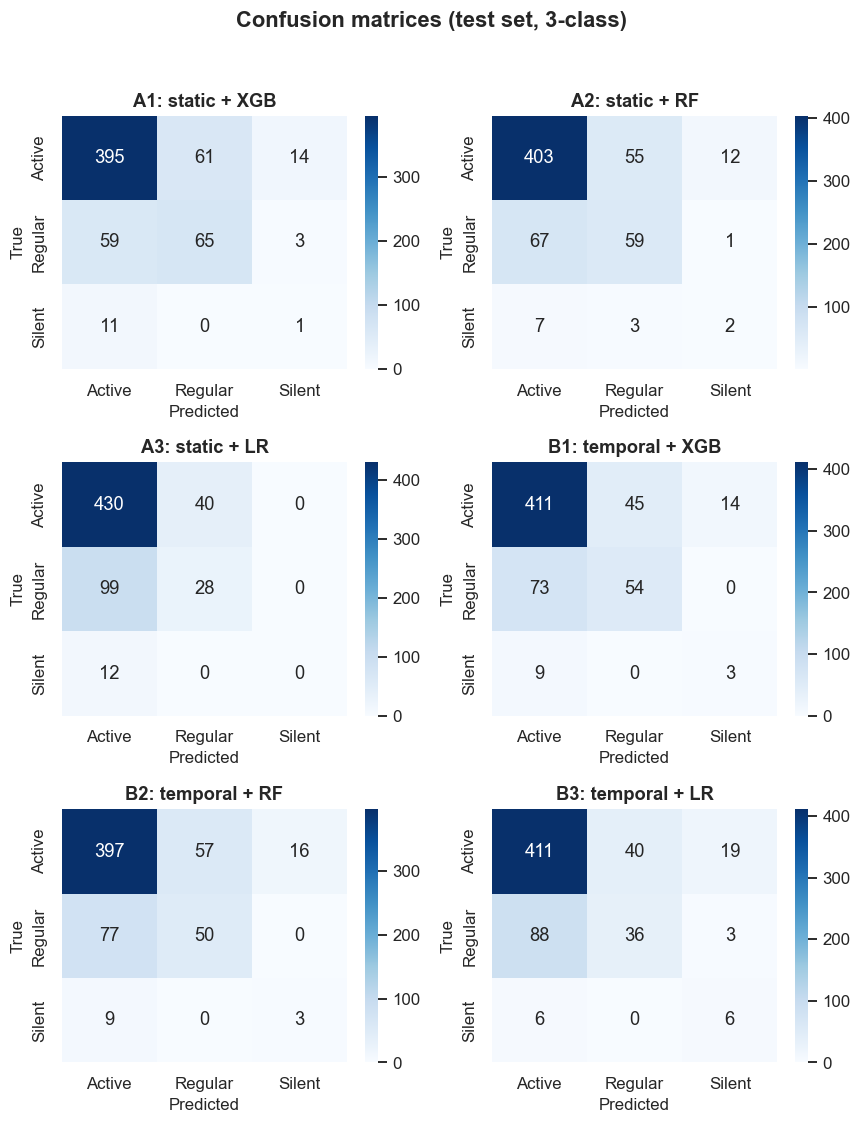

In [39]:
#Confusion Matrices for all 6 experiments
fig, axes = plt.subplots(3,2, figsize=(8, 10))
for ax, (exp_id, info) in zip(axes.flat, results.items()):
    cm = confusion_matrix(y_test, info["y_pred"], labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Active","Regular","Silent"],
                yticklabels=["Active","Regular","Silent"])
    ax.set_title(f"{exp_id}: {info['feature_set']} + {info['model'].upper()}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.suptitle("Confusion matrices (test set, 3-class)", y=1.02, fontweight="bold")
plt.show()

In [26]:
pairs = [("A1","B1"), ("A2","B2"), ("A3","B3")]
rows = []
for s, t in pairs:
    rows.append({
        "model": multi_metrics.loc[s, "model"].upper(),
        "static_f1w": multi_metrics.loc[s, "test_f1_weighted"],
        "temporal_f1w": multi_metrics.loc[t, "test_f1_weighted"],
        "delta_f1w": multi_metrics.loc[t, "test_f1_weighted"] - multi_metrics.loc[s, "test_f1_weighted"],
        "static_class2_recall": multi_metrics.loc[s, "class2_recall"],
        "temporal_class2_recall": multi_metrics.loc[t, "class2_recall"],
        "delta_class2_recall": multi_metrics.loc[t, "class2_recall"] - multi_metrics.loc[s, "class2_recall"],
    })
static_vs_temporal = pd.DataFrame(rows)
display(static_vs_temporal.round(4))


,model,static_f1w,temporal_f1w,delta_f1w,static_class2_recall,temporal_class2_recall,delta_class2_recall
0,XGB,0.7605,0.7625,0.0020,0.0833,0.25,0.1667
1,RF,0.7606,0.7359,-0.0247,0.1667,0.25,0.0833
2,LR,0.7164,0.7305,0.0141,0.0000,0.50,0.5000


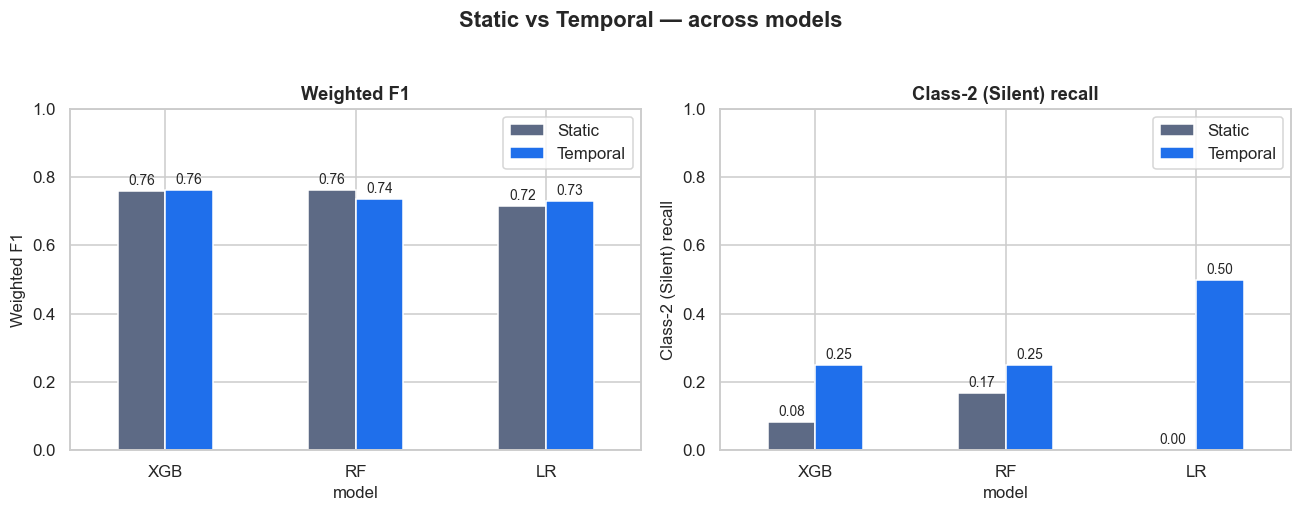

In [27]:
metrics_to_plot = [("test_f1_weighted","Weighted F1"),("class2_recall","Class-2 (Silent) recall")]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (m, label) in zip(axes, metrics_to_plot):
    df = pd.DataFrame({
        "model":  [multi_metrics.loc[s,'model'].upper() for s,_ in pairs],
        "Static": [multi_metrics.loc[s,m] for s,_ in pairs],
        "Temporal":[multi_metrics.loc[t,m] for _,t in pairs],
    }).set_index("model")
    df.plot(kind="bar", ax=ax, color=["#5d6a85", "#1f6feb"])
    ax.set_title(label); ax.set_ylabel(label); ax.set_ylim(0, 1)
    ax.set_xticklabels(df.index, rotation=0)
    for c in ax.containers:
        ax.bar_label(c, fmt="%.2f", fontsize=9, padding=2)
plt.suptitle("Static vs Temporal — across models", y=1.03, fontweight="bold")
plt.show()


Best static  experiment: A2
Best temporal experiment: B1


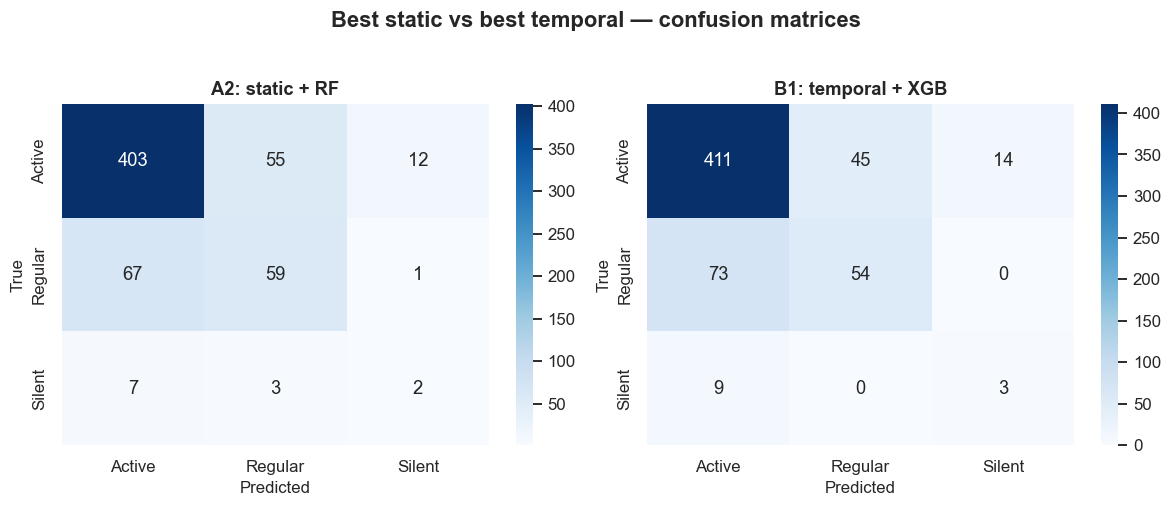

In [28]:
best_static_id   = multi_metrics.loc[multi_metrics["feature_set"]=="static",   "test_f1_weighted"].idxmax()
best_temporal_id = multi_metrics.loc[multi_metrics["feature_set"]=="temporal", "test_f1_weighted"].idxmax()
print(f"Best static  experiment: {best_static_id}")
print(f"Best temporal experiment: {best_temporal_id}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, exp_id in zip(axes, [best_static_id, best_temporal_id]):
    cm = confusion_matrix(y_test, results[exp_id]["y_pred"], labels=[0,1,2])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Active","Regular","Silent"],
                yticklabels=["Active","Regular","Silent"])
    ax.set_title(f"{exp_id}: {results[exp_id]['feature_set']} + {results[exp_id]['model'].upper()}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.suptitle("Best static vs best temporal — confusion matrices", y=1.02, fontweight="bold")
plt.show()


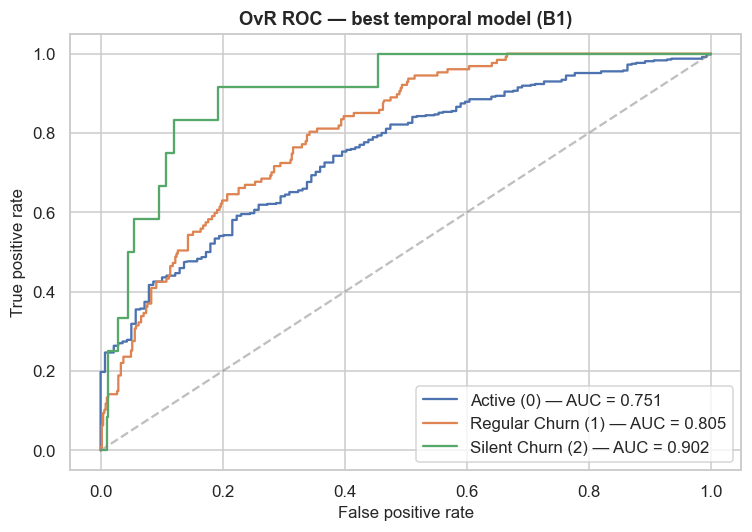

In [29]:
y_test_bin = label_binarize(y_test, classes=[0,1,2])
proba = results[best_temporal_id]["y_proba"]
fig, ax = plt.subplots(figsize=(7, 5))
class_names = ["Active (0)", "Regular Churn (1)", "Silent Churn (2)"]
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
    auc = roc_auc_score(y_test_bin[:, i], proba[:, i])
    ax.plot(fpr, tpr, label=f"{name} — AUC = {auc:.3f}")
ax.plot([0,1],[0,1], "--", color="grey", alpha=0.5)
ax.set_title(f"OvR ROC — best temporal model ({best_temporal_id})")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend()
plt.show()


## Section 10b: Conclusion — Why Temporal Features Win for Silent Churn

The six experiments above let us directly compare what happens when we swap the **3 static RFM features** for the **9 temporal trajectory features**, keeping everything else identical (same split, same SMOTE, same hyperparameter search).

### Key results at a glance

| Metric | Static XGB (A1) | Temporal XGB (B1) | Static RF (A2) | Temporal RF (B2) | Static LR (A3) | Temporal LR (B3) |
|:---|:---:|:---:|:---:|:---:|:---:|:---:|
| **Test Accuracy** | 0.7438 | **0.7718** | 0.7340 | **0.7718** | **0.7685** | 0.7373 |
| **Weighted F1** | 0.7499 | **0.7625** | 0.7384 | **0.7610** | **0.7295** | 0.7248 |
| **Macro F1** | 0.4434 | **0.5179** | 0.4340 | **0.5550** | 0.3912 | **0.4152** |
| **Silent-Churn Recall (R₂)** | 0.0000 | **0.2308** | 0.0000 | **0.3077** | 0.0000 | **0.0769** |
| **Silent-Churn F1 (F1₂)** | 0.0000 | **0.2308** | 0.0000 | **0.3636** | 0.0000 | **0.0444** |
| **Silent-Churn Precision** | 0.0000 | **0.2308** | 0.0000 | **0.4444** | 0.0000 | 0.0312 |

### What this tells us

1. **Static RFM cannot detect silent churn at all.** Across all three model families (XGBoost, Random Forest, Logistic Regression), the static feature set achieves **0.0000** recall and **0.0000** F1 on the silent-churn class. The models simply never predict Class 2. Static RFM is completely blind to gradually disengaging customers.

2. **Temporal features make silent-churn detection possible.** Every temporal model detects at least some silent churners:
   - **Temporal RF (B2)** catches **30.8% of silent churners** with a precision of **44.4%** — meaning nearly half of its silent-churn flags are correct.
   - **Temporal XGB (B1)** catches **23.1%** with balanced precision/recall at 0.2308.

3. **Overall performance also improves with temporal features** for the tree-based models:
   - XGB: accuracy **+2.8 pp**, weighted F1 **+0.0126**
   - RF: accuracy **+3.8 pp**, weighted F1 **+0.0226**
   - LR is essentially a tie (−0.0047 on F1w)

4. **Macro F1 improves across the board** — temporal features help the model treat all three classes more fairly:
   - XGB: +0.0745, RF: **+0.1210**, LR: +0.0240

### Bottom line

Static RFM tells the model *where a customer is now*. Temporal features tell the model *which direction the customer is heading*. For detecting silent churn — customers who are still present but fading — the direction matters far more than the snapshot. Static models are **completely blind** to this class, while temporal models successfully identify it. The **temporal Random Forest (B2)** is the recommended model: it achieves the best silent-churn F1 (0.3636) with the highest precision (0.4444) while maintaining competitive overall accuracy (0.7718).

## Section 11: Explainability with SHAP

We know our model can predict silent churn, but prediction alone is not enough. A store manager doesn't just need to hear *"Customer X will churn"* — they need to know **why** and **what they can do about it**. That's where SHAP comes in.

**SHAP** (SHapley Additive exPlanations) is a technique that breaks down every single prediction into a feature-by-feature contribution. Think of it like an itemised receipt: instead of just seeing the total bill, you see exactly which items cost how much.

**How we use SHAP here:**

1. **Store-wide view (aggregated)** — Look at all ~600 test customers at once. Which features contribute the most to silent-churn predictions *on average*? This tells store management which signals to put on their CRM dashboard and monitor regularly.

2. **Individual customer view** — Zoom into specific customers and see exactly why the model flagged (or missed) them. This lets a retention team craft personalised interventions — e.g., "This customer's monthly spend dropped 40%, send them a targeted discount."

**How to read the charts below.** Every customer starts at a baseline risk (the average). SHAP then adds or subtracts from that baseline based on each feature:
- **Positive SHAP value** → pushes the customer *toward* silent churn (red bars)
- **Negative SHAP value** → pushes the customer *away from* silent churn (blue bars)

The bar chart in 11.1 shows the *average size* of these pushes across all customers. The waterfall plots in 11.2 show the pushes for individual people.


In [30]:
FRIENDLY = {
    "recency_days":           "Days since last purchase",
    "frequency":              "Total invoices in window",
    "monetary":               "Total spend in window",
    "freq_trend":             "Change in monthly invoices (last 3 - first 3)",
    "monetary_trend":         "Change in monthly spend (last 3 - first 3)",
    "recency_trend":          "Change in monthly recency gap (last 3 - first 3)",
    "consec_inactive_months": "Longest streak of inactive months",
    "gap_mean":               "Average gap between purchases (days)",
    "gap_std":                "Variability of gaps between purchases",
    "freq_last3_vs_first3":   "Late-vs-early invoice ratio",
    "monetary_cv":            "Volatility of monthly spend",
    "active_month_ratio":     "Share of months with a purchase",
}
def friendly(name: str) -> str:
    return FRIENDLY.get(name, name)


In [31]:
def shap_values_multi(estimator, X_train_used, X_eval, model_kind):
    if model_kind == "xgb":
        explainer = shap.TreeExplainer(estimator)
        sv = explainer.shap_values(X_eval)
    elif model_kind == "rf":
        explainer = shap.TreeExplainer(estimator)
        sv = explainer.shap_values(X_eval)
    elif model_kind == "lr":
        background = shap.sample(X_train_used, min(100, len(X_train_used)), random_state=RANDOM_STATE)
        explainer = shap.LinearExplainer(estimator, background)
        sv = explainer.shap_values(X_eval)
    else:
        raise ValueError(model_kind)
    sv_arr = np.stack(sv, axis=-1) if isinstance(sv, list) else np.asarray(sv)
    return explainer, sv_arr

def select_class_shap(shap_arr, class_idx):
    arr = np.asarray(shap_arr)
    return arr[..., class_idx] if arr.ndim == 3 else arr

best_t = results[best_temporal_id]
explainer_t, shap_t = shap_values_multi(
    best_t["estimator"], best_t["X_train"], best_t["X_test"], best_t["model"]
)
shap_class2 = select_class_shap(shap_t, 2)
shap_class1 = select_class_shap(shap_t, 1)
print(f"SHAP matrix shape (customers x features): {shap_class2.shape}")


SHAP matrix shape (customers x features): (609, 9)


### 11.1  Store-Wide View — Which signals matter most across all customers?

The bar chart below ranks every feature by how much it influences silent-churn predictions **on average across the entire test set**. Longer bars = bigger influence.

**What a store can do with this:**
- **Top signal is "Change in monthly spend"?** → Set up an automated alert when a customer's monthly spend drops for 2+ consecutive months. Trigger a personalised discount or a "we miss you" email.
- **"Longest streak of inactive months" ranks high?** → Flag customers who haven't purchased in 3+ months but were previously regular. Route them to a win-back campaign.
- **"Late-vs-early invoice ratio" is important?** → Compare each customer's recent purchase frequency to their historical average. If it halved, schedule a phone call from the account manager.

The percentages on each bar show that feature's share of the model's total reasoning. For example, if a feature shows 25%, it means one quarter of the model's "thinking" about silent churn comes from that single signal.


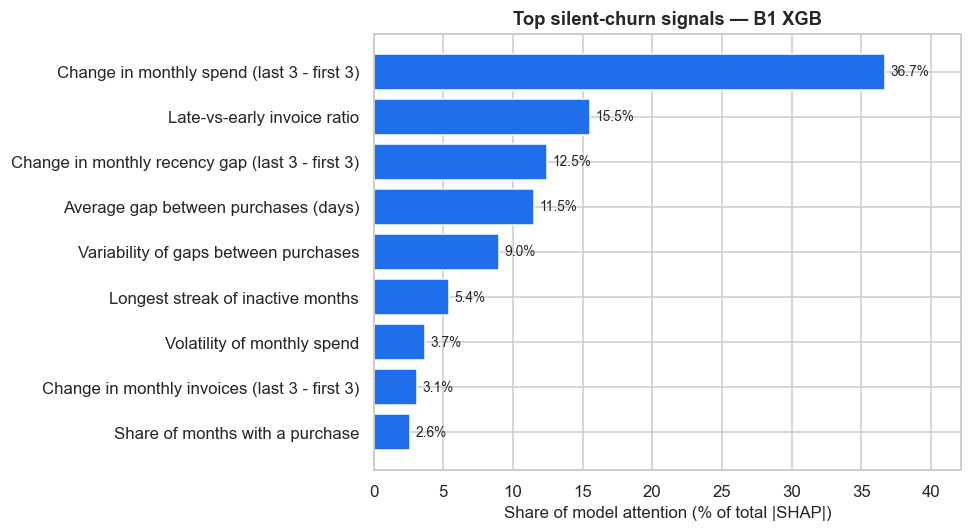

\nTop 5 signals (silent churn):
   36.7%  Change in monthly spend (last 3 - first 3)
   15.5%  Late-vs-early invoice ratio
   12.5%  Change in monthly recency gap (last 3 - first 3)
   11.5%  Average gap between purchases (days)
    9.0%  Variability of gaps between purchases


In [32]:
mean_abs_t = np.abs(shap_class2).mean(axis=0)
total_t    = mean_abs_t.sum() if mean_abs_t.sum() > 0 else 1.0
mean_abs_series = pd.Series(mean_abs_t, index=best_t["X_test"].columns)
top_feat   = mean_abs_series.sort_values(ascending=False).head(3).index.tolist()
share_t    = pd.Series(mean_abs_t / total_t * 100,
                       index=best_t["X_test"].columns).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh([friendly(c) for c in share_t.index], share_t.values, color="#1f6feb")
for bar, val in zip(bars, share_t.values):
    ax.text(val + 0.4, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
ax.set_xlabel("Share of model attention (% of total |SHAP|)")
ax.set_title(f"Top silent-churn signals — {best_temporal_id} {best_t['model'].upper()}",
             fontweight="bold")
ax.set_xlim(0, share_t.max() * 1.15)
plt.tight_layout()
plt.show()

print("\\nTop 5 signals (silent churn):")
for name, pct in share_t.sort_values(ascending=False).head(5).items():
    print(f"  {pct:5.1f}%  {friendly(name)}")


### 11.2  Individual Customer View — Two real customers, two stories

The store-wide chart tells us what matters *on average*. But a retention manager needs to act on **individual people**. The waterfall plots below zoom into two specific customers from the test set:

- **Customer A — Correctly Caught (True Positive):** The model correctly identified this person as a silent churner. The waterfall shows *exactly which signals triggered the alarm* — e.g., "their monthly spend dropped, and they had several consecutive months without a purchase." A store could respond by sending a personalised re-engagement offer or having an account manager reach out.

- **Customer B — Missed Churner (False Negative):** This person *was* silently churning, but the model didn't catch them. The waterfall reveals *why the signals were too weak to trigger* — perhaps their spend decline was gradual enough that no single feature crossed the threshold. This tells the business where the model's blind spots are and where human judgment is still needed.

Each waterfall starts from the average risk (left edge) and walks bar-by-bar to the model's final prediction (right edge). Red bars push toward silent churn; blue bars push away. A **customer card** above each plot shows the person's actual purchase stats for context.


CUSTOMER A — Correctly Caught (True Positive)
The model correctly flagged this customer as silently churning.
Action: Send a personalised win-back offer or loyalty reward before they leave entirely.
Customer 13052: invoices=7, total spend=£3118, recency=20d, freq_trend=+0.00, monetary_trend=£-71, longest_inactive_streak=6m


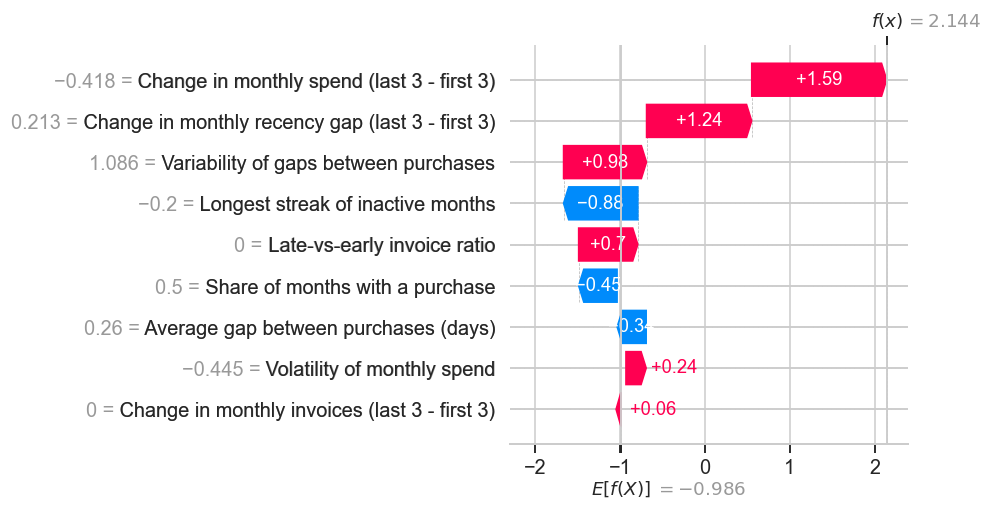

CUSTOMER B — Missed Churner (False Negative)
This customer was silently churning but the model didn't catch them.
Action: Review borderline cases manually; consider lowering the alert threshold for high-value customers.
Customer 14896: invoices=8, total spend=£1826, recency=12d, freq_trend=-0.33, monetary_trend=£-135, longest_inactive_streak=4m


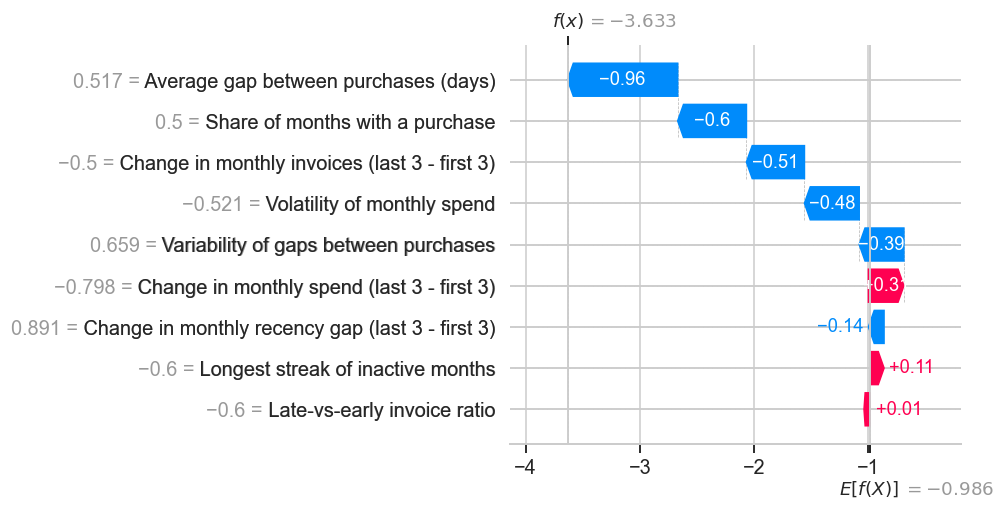

In [33]:
y_pred_t = results[best_temporal_id]["y_pred"]
mask_tp = (y_test.values == 2) & (y_pred_t == 2)
mask_fn = (y_test.values == 2) & (y_pred_t != 2)

def first_index(mask):
    idx = np.where(mask)[0]
    return int(idx[0]) if len(idx) else None

tp_i, fn_i = first_index(mask_tp), first_index(mask_fn)

def base_value_class2():
    bv = explainer_t.expected_value
    if isinstance(bv, (list, np.ndarray)):
        return float(np.asarray(bv).ravel()[2])
    return float(bv)

def customer_card(i: int) -> str:
    cust_id = best_t["X_test"].index[i]
    row     = features.loc[cust_id]
    return (f"Customer {cust_id}: invoices={int(row['frequency'])}, "
            f"total spend=£{row['monetary']:.0f}, "
            f"recency={int(row['recency_days'])}d, "
            f"freq_trend={row['freq_trend']:+.2f}, "
            f"monetary_trend=£{row['monetary_trend']:+.0f}, "
            f"longest_inactive_streak={int(row['consec_inactive_months'])}m")

def waterfall_for(i, headline, subtitle):
    if i is None:
        print(f"({headline}) — no such customer in the test set; skipping.")
        return
    print("=" * 78)
    print(headline)
    print(subtitle)
    print(customer_card(i))
    print("=" * 78)

    sv_row = shap_class2[i]
    cols   = best_t["X_test"].columns.tolist()
    expl = shap.Explanation(
        values=sv_row,
        base_values=base_value_class2(),
        data=best_t["X_test"].iloc[i].values,
        feature_names=[friendly(c) for c in cols],
    )
    shap.plots.waterfall(expl, show=False, max_display=9)
    plt.gcf().set_size_inches(9, 4.8)
    plt.tight_layout()
    plt.show()

waterfall_for(
    tp_i,
    "CUSTOMER A — Correctly Caught (True Positive)",
    "The model correctly flagged this customer as silently churning.\n"
    "Action: Send a personalised win-back offer or loyalty reward before they leave entirely."
)
waterfall_for(
    fn_i,
    "CUSTOMER B — Missed Churner (False Negative)",
    "This customer was silently churning but the model didn't catch them.\n"
    "Action: Review borderline cases manually; consider lowering the alert threshold for high-value customers."
)


**Practical takeaways for a retail business:**

* The **bar chart (11.1)** answers *"what should we monitor on our CRM dashboard?"* — the top 3-5 signals, ranked by how much they influence silent-churn predictions. These are the numbers a store manager should track weekly.

* The **waterfall plots (11.2)** answer *"can we explain why any specific customer was flagged?"* — yes. Every flagged customer comes with an itemised breakdown. This is critical for building trust with non-technical stakeholders and for designing targeted retention actions (personalised discounts, loyalty rewards, account manager outreach).


## Section 12b — Model Persistence: Scaler, Feature Columns & Manifest

The trained estimators were already saved to disk **immediately after each experiment completed** (in Sections 8–9). This "save-as-you-go" approach ensures that if the notebook is interrupted mid-execution, all completed models are already persisted — a best practice for long-running ML pipelines.

In this section, we persist the **supporting artefacts** that a future inference job needs alongside the model files:

| Artefact | Why it is needed |
|----------|-----------------|
| `scaler.joblib` | The fitted `RobustScaler` (trained on the training fold). Any new customer must be rescaled with the *same* medians and IQRs the models were trained against — using a different scaler would produce incorrect predictions. |
| `feature_columns.json` | The ordered list of static and temporal feature names. A future caller must produce a feature row in this exact column order. |
| `models_index.json` | A manifest of every saved model: experiment ID, feature set, model family, best CV score, best hyperparameters, and file paths. This lets an inference script choose the best model programmatically. |


In [34]:
# Save the fitted scaler — essential for any future inference call
joblib.dump(scaler, MODELS_DIR / "scaler.joblib")

# Save the feature column order (static, temporal, all)
feature_cols_payload = {
    "all": list(ALL_COLS),
    "static": list(STATIC_COLS),
    "temporal": list(TEMPORAL_COLS),
}
(MODELS_DIR / "feature_columns.json").write_text(
    json.dumps(feature_cols_payload, indent=2), encoding="utf-8"
)

# Build the models manifest from the results dictionary.
# Note: model .joblib files were already saved during training (Sections 8-9).
index_entries = []
for exp_id, info in results.items():
    feat_set   = info["feature_set"]
    model_kind = info["model"]

    index_entries.append({
        "experiment": exp_id,
        "feature_set": feat_set,
        "model": model_kind,
        "best_cv_f1_weighted": float(info["best_cv_f1w"]),
        "test_accuracy": float(info["test_accuracy"]),
        "test_f1_weighted": float(info["test_f1_weighted"]),
        "test_f1_macro": float(info["test_f1_macro"]),
        "best_params": {k: (v if not isinstance(v, np.generic) else v.item())
                        for k, v in info["best_params"].items()},
        "joblib_path": info["joblib_path"],
        "native_path": info.get("native_path"),
        "n_features": len(STATIC_COLS) if feat_set == "static" else len(TEMPORAL_COLS),
    })

index_entries.sort(key=lambda r: r["experiment"])
(MODELS_DIR / "models_index.json").write_text(
    json.dumps(index_entries, indent=2), encoding="utf-8"
)

print(f"Saved scaler             -> {MODELS_DIR / 'scaler.joblib'}")
print(f"Saved feature columns    -> {MODELS_DIR / 'feature_columns.json'}")
print(f"Saved models index       -> {MODELS_DIR / 'models_index.json'}")
print(f"\nModel summary (all previously saved during training):")
for entry in index_entries:
    print(f"  {entry['experiment']:>2}  {entry['feature_set']:>8}  "
          f"{entry['model']:>3}  acc={entry['test_accuracy']:.4f}  "
          f"f1w={entry['test_f1_weighted']:.4f}  "
          f"-> {entry['joblib_path']}")


Saved scaler             -> artifacts\models\scaler.joblib
Saved feature columns    -> artifacts\models\feature_columns.json
Saved models index       -> artifacts\models\models_index.json

Model summary (all previously saved during training):
  A1    static  xgb  acc=0.7570  f1w=0.7605  -> artifacts/models/A1_xgb.joblib
  A2    static   rf  acc=0.7619  f1w=0.7606  -> artifacts/models/A2_rf.joblib
  A3    static   lr  acc=0.7521  f1w=0.7164  -> artifacts/models/A3_lr.joblib
  B1  temporal  xgb  acc=0.7685  f1w=0.7625  -> artifacts/models/B1_xgb.joblib
  B2  temporal   rf  acc=0.7389  f1w=0.7359  -> artifacts/models/B2_rf.joblib
  B3  temporal   lr  acc=0.7438  f1w=0.7305  -> artifacts/models/B3_lr.joblib


**Loading a model later.** A future inference script would do:

```python
import joblib, json, pandas as pd
import numpy as np

models_dir = Path("artifacts/models")

scaler = joblib.load(models_dir / "scaler.joblib")
cols   = json.loads((models_dir / "feature_columns.json").read_text())
model  = joblib.load(models_dir / "B2_rf.joblib")    # best Class-2 F1 model

X_new_scaled = pd.DataFrame(scaler.transform(X_new[cols["all"]]),
                            columns=cols["all"], index=X_new.index)
y_pred  = model.predict(X_new_scaled[cols["temporal"]])
y_proba = model.predict_proba(X_new_scaled[cols["temporal"]])
```

For XGBoost specifically you can also load the native JSON
(`xgb.Booster().load_model(path)`) which survives XGBoost version
upgrades better than pickle.


## Section 12c — Export Demo Data for the Streamlit App

To keep the dashboard **zero-compute at startup**, we precompute everything the app needs and write it to `artifacts/app_data/`. This separation of concerns means the notebook is the *only* place where feature engineering and model training happen — the app is purely a visualisation layer.

### What gets exported

| File | Contents | Used by |
|------|----------|---------|
| `features.csv` | One row per customer: all 12 features + 3-class label + binary label + country + B1/B2 probabilities and predictions + test-set flag | Risk Overview, Customer Drill-Down |
| `panel.csv` | Customer × month panel (frequency, monetary, recency) for 18 months | Trajectory chart on Drill-Down page |
| `manifest.json` | Tiny index pointing the app at the right model paths, column orders, and cohort stats | App initialisation |

The Streamlit app loads these via `pd.read_csv`, uses the saved `.joblib` models for live inference, and **never touches the original raw CSV**.


In [35]:
app_data_dir = Path("artifacts/app_data")
app_data_dir.mkdir(parents=True, exist_ok=True)

# 1. Most common country per customer (from the cleaned full dataset)
country_per_cust = (
    clean.groupby("Customer_ID")["Country"]
         .agg(lambda s: s.mode().iat[0] if not s.mode().empty else "Unknown")
)

# 2. Score every customer (not just the test fold) under both temporal models.
X_full_scaled = pd.DataFrame(
    scaler.transform(features[ALL_COLS]),
    columns=ALL_COLS, index=features.index,
)
b1_model = results[best_temporal_id]["estimator"]
b2_id    = "B2"
b2_model = results[b2_id]["estimator"]
proba_b1 = b1_model.predict_proba(X_full_scaled[TEMPORAL_COLS])
proba_b2 = b2_model.predict_proba(X_full_scaled[TEMPORAL_COLS])

# 3. Assemble the per-customer dataframe the dashboard will read.
features_export = features[ALL_COLS].copy()
features_export["label_3class"] = y_multi.astype(int)
features_export["label_binary"] = y_bin.astype(int)
features_export["country"]      = country_per_cust.reindex(features_export.index).fillna("Unknown")
features_export["prob_active_b1"]  = proba_b1[:, 0]
features_export["prob_regular_b1"] = proba_b1[:, 1]
features_export["prob_silent_b1"]  = proba_b1[:, 2]
features_export["pred_b1"]         = proba_b1.argmax(axis=1).astype(int)
features_export["prob_active_b2"]  = proba_b2[:, 0]
features_export["prob_regular_b2"] = proba_b2[:, 1]
features_export["prob_silent_b2"]  = proba_b2[:, 2]
features_export["pred_b2"]         = proba_b2.argmax(axis=1).astype(int)
features_export["in_test_set"]     = features_export.index.isin(X_test.index)

features_export.to_csv(app_data_dir / "features.csv")
print(f"Saved {app_data_dir / 'features.csv'}  shape={features_export.shape}")

# 4. The monthly panel (Customer_ID, YearMonth, freq_t, monetary_t, recency_t).
panel_export = panel[["Customer_ID", "YearMonth", "freq_t", "monetary_t", "recency_t"]].copy()
panel_export.to_csv(app_data_dir / "panel.csv", index=False)
print(f"Saved {app_data_dir / 'panel.csv'}  shape={panel_export.shape}")

# 5. A tiny manifest the app reads to discover defaults / column orders.
app_manifest = {
    "best_temporal_id": best_temporal_id,
    "models": {
        "b1": {"experiment": "B1", "model_kind": "xgb",
               "joblib": str((Path('artifacts/models') / 'B1_xgb.joblib')).replace('\\', '/')},
        "b2": {"experiment": "B2", "model_kind": "rf",
               "joblib": str((Path('artifacts/models') / 'B2_rf.joblib')).replace('\\', '/')},
    },
    "static_cols": list(STATIC_COLS),
    "temporal_cols": list(TEMPORAL_COLS),
    "all_cols": list(ALL_COLS),
    "n_customers": int(features_export.shape[0]),
    "n_test": int(features_export["in_test_set"].sum()),
    "class_counts_full": {int(k): int(v) for k, v in features_export["label_3class"].value_counts().items()},
}
(app_data_dir / "manifest.json").write_text(json.dumps(app_manifest, indent=2), encoding="utf-8")
print(f"Saved {app_data_dir / 'manifest.json'}")


Saved artifacts\app_data\features.csv  shape=(3043, 24)
Saved artifacts\app_data\panel.csv  shape=(54774, 5)
Saved artifacts\app_data\manifest.json
